In [1]:
%load_ext autoreload
%autoreload 2

In [35]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import pathlib
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from torchvision import transforms
import os
from visualisation import visualize_dataset, plot_roc_curve
from save_and_load import save_model, load_model
from train import train_model, evaluate_model
from sampling import get_upsampled_sampler, downsample_dataset
from models import LensCNN, ResNetFineTune

In [36]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

device

'cuda'

In [4]:
class LensDataset(Dataset):
    def __init__(self, lens_dir, nonlens_dir, transform=None):
        """
        Args:
            lens_dir (str): Path to directory containing lens .npy files.
            nonlens_dir (str): Path to directory containing non-lens .npy files.
            transform (callable, optional): Optional transform to apply on images.
        """
        self.lens_files = [os.path.join(lens_dir, f) for f in os.listdir(lens_dir) if f.endswith('.npy')]
        self.nonlens_files = [os.path.join(nonlens_dir, f) for f in os.listdir(nonlens_dir) if f.endswith('.npy')]

        # Labels: 1 for lenses, 0 for non-lenses
        self.data = [(f, 1) for f in self.lens_files] + [(f, 0) for f in self.nonlens_files]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        file_path, label = self.data[idx]
        image = np.load(file_path)  # Load .npy file (shape: 3x64x64)

        image = torch.tensor(image, dtype=torch.float32)  # Convert to tensor

        if self.transform:
            image = self.transform(image)  # Apply any transformations

        return image, torch.tensor(label, dtype=torch.long)


In [39]:
# Paths to dataset directories
train_lens_dir = "dataset/lens-finding-test/train_lenses"
train_nonlens_dir = "dataset/lens-finding-test/train_nonlenses"
test_lens_dir = "dataset/lens-finding-test/test_lenses"
test_nonlens_dir = "dataset/lens-finding-test/test_nonlenses"

# Create dataset objects
train_dataset = LensDataset(train_lens_dir, train_nonlens_dir)
test_dataset = LensDataset(test_lens_dir, test_nonlens_dir)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Example usage
for images, labels in train_loader:
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels: {labels}")
    break

Batch of images shape: torch.Size([32, 3, 64, 64])
Batch of labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0])


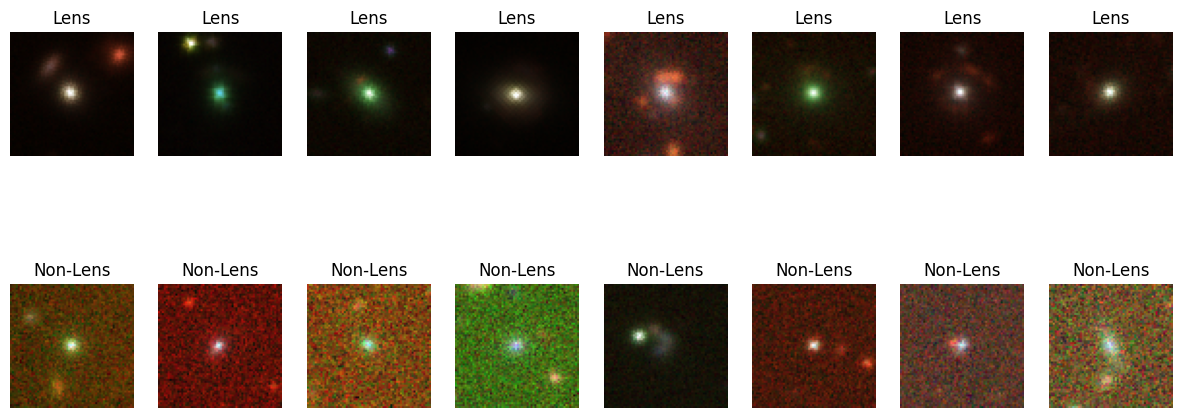

In [6]:
# Visualize an equal number of lens and non-lens images
visualize_dataset(train_dataset, num_images=8)

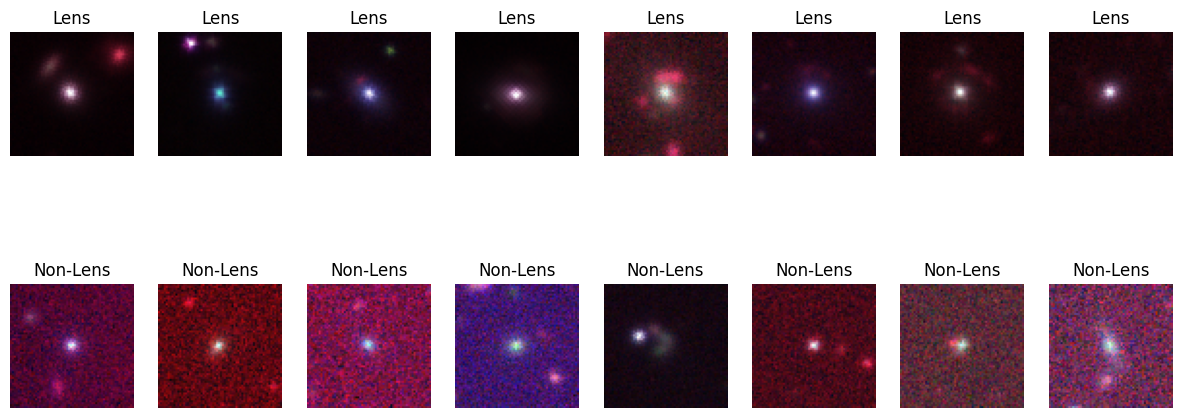

In [7]:
def visualize_dataset_rbg(dataset, num_images=4):
    """
    Visualizes an equal number of lens and non-lens images in RBG format.

    Args:
        dataset (LensDataset): The dataset object.
        num_images (int): Number of images to display per class.
    """
    lens_images = []
    nonlens_images = []

    # Collect equal samples from both classes
    for img, label in dataset:
        if label == 1 and len(lens_images) < num_images:
            lens_images.append((img, "Lens"))
        elif label == 0 and len(nonlens_images) < num_images:
            nonlens_images.append((img, "Non-Lens"))

        if len(lens_images) >= num_images and len(nonlens_images) >= num_images:
            break

    # Combine both classes
    images = lens_images + nonlens_images

    # Plot images
    fig, axes = plt.subplots(2, num_images, figsize=(15, 6))

    for i, (img, label) in enumerate(images):
        ax = axes[i // num_images, i % num_images]
        
        img = img.numpy()  # Convert tensor to NumPy
        img = img[[0, 2, 1], :, :]  # Swap G and B channels to get RBG
        img = img.transpose(1, 2, 0)  # Convert (3, 64, 64) → (64, 64, 3)

        ax.imshow(img)
        ax.set_title(label)
        ax.axis("off")

    plt.show()

# Visualize dataset with RBG format
visualize_dataset_rbg(train_dataset, num_images=8)

## Direct Training (No Technique to address class imbalance)

### LensCNN

In [11]:
model = LensCNN(num_classes=2).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model_path = "saved_models/cnn_direct.pth"


# Train the model
train_model(model, train_loader, test_loader, optimizer=optimizer, criterion=criterion, save_path=model_path, device=device, epochs=50, patience=7)

load_model(model, model_path)

# Evaluate on test set
test_acc, test_auc = evaluate_model(model, test_loader, device)
print(f"Test Accuracy: {test_acc}, Test AUC: {test_auc}")

Epoch 1/50: 100%|██████████| 951/951 [00:11<00:00, 82.93it/s]


Epoch 1: Loss = 153.91403709165752, Train Acc = 0.9414898865318204, Val Acc = 0.9824936386768448, AUC = 0.9188488886252957
Model saved to saved_models/cnn_direct.pth


Epoch 2/50: 100%|██████████| 951/951 [00:11<00:00, 86.31it/s]


Epoch 2: Loss = 126.6178364045918, Train Acc = 0.9473112974839665, Val Acc = 0.9803053435114504, AUC = 0.9242499126847624
Model saved to saved_models/cnn_direct.pth


Epoch 3/50: 100%|██████████| 951/951 [00:11<00:00, 84.03it/s]


...

Epoch 24: Loss = 41.63323665218195, Train Acc = 0.9837855615852655, Val Acc = 0.9889567430025445, AUC = 0.970255355883729


Epoch 25/50: 100%|██████████| 951/951 [00:11<00:00, 80.81it/s]


Epoch 25: Loss = 39.052231545210816, Train Acc = 0.9851998026640355, Val Acc = 0.973384223918575, AUC = 0.9708160185569591


Epoch 26/50: 100%|██████████| 951/951 [00:12<00:00, 77.88it/s]


Epoch 26: Loss = 38.97343455028022, Train Acc = 0.9849037987173163, Val Acc = 0.9921119592875318, AUC = 0.9758229708268259
Early stopping triggered after 26 epochs.
Model loaded from saved_models/cnn_direct.pth
Test Accuracy: 0.9838676844783715, Test AUC: 0.9762768782660841


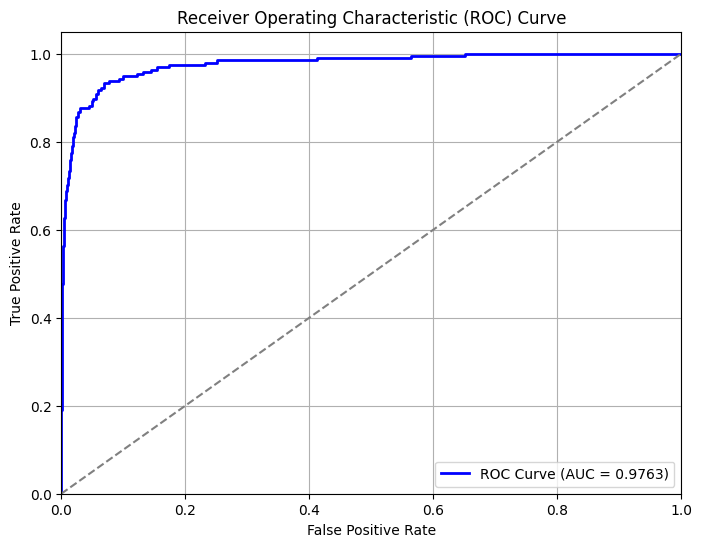

In [13]:
plot_roc_curve(model, test_loader, device)

### ResNet Finetune

In [40]:
model = ResNetFineTune(num_classes=2, freeze_blocks=1).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model_path = "saved_models/resnet_direct.pth"


# Train the model
train_model(model, train_loader, test_loader, optimizer=optimizer, criterion=criterion, save_path=model_path, device=device, epochs=50, patience=7)

load_model(model, model_path)

# Evaluate on test set
test_acc, test_auc = evaluate_model(model, test_loader, device)
print(f"Test Accuracy: {test_acc}, Test AUC: {test_auc}")

Epoch 1/50: 100%|██████████| 951/951 [00:29<00:00, 32.71it/s]


Epoch 1: Loss = 123.96830740012228, Train Acc = 0.9500740009866798, Val Acc = 0.9834096692111959, AUC = 0.9586074372813002
Model saved to saved_models/resnet_direct.pth


Epoch 2/50: 100%|██████████| 951/951 [00:28<00:00, 33.05it/s]


Epoch 2: Loss = 100.08872656151652, Train Acc = 0.958493668804473, Val Acc = 0.9894147582697201, AUC = 0.946454210571404


Epoch 3/50: 100%|██████████| 951/951 [00:28<00:00, 32.84it/s]


...

Epoch 12: Loss = 32.140170994669916, Train Acc = 0.9869758263443512, Val Acc = 0.9878880407124682, AUC = 0.974899076764921


Epoch 13/50: 100%|██████████| 951/951 [00:28<00:00, 33.54it/s]


Epoch 13: Loss = 28.790536059786064, Train Acc = 0.9885216247327742, Val Acc = 0.9916539440203562, AUC = 0.9787820677566244


Epoch 14/50: 100%|██████████| 951/951 [00:28<00:00, 33.44it/s]


Epoch 14: Loss = 21.83450045519055, Train Acc = 0.9911198815984213, Val Acc = 0.9888549618320611, AUC = 0.9766248212508815
Early stopping triggered after 14 epochs.
Model loaded from saved_models/resnet_direct.pth
Test Accuracy: 0.991145038167939, Test AUC: 0.9813188884276008


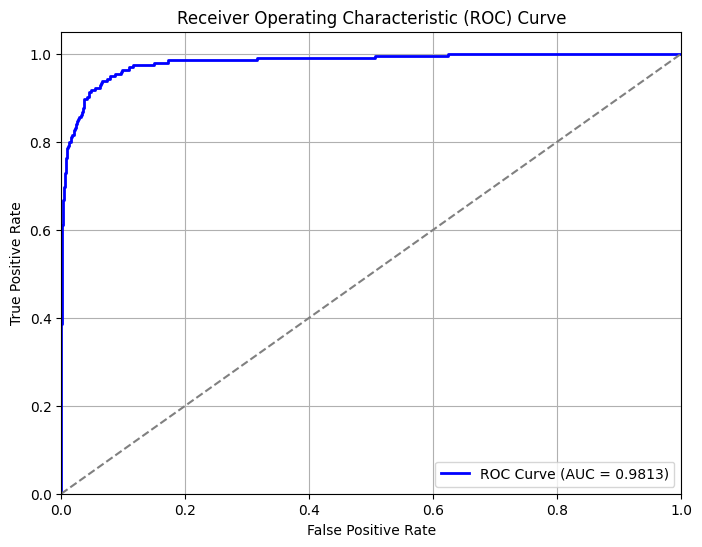

In [41]:
plot_roc_curve(model, test_loader, device)

## Upsampling the minority class

In [42]:
upsampled_sampler = get_upsampled_sampler(train_dataset)
train_loader = DataLoader(train_dataset, batch_size=32, sampler=upsampled_sampler)

### LensCNN

In [15]:
model = LensCNN(num_classes=2).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model_path = "saved_models/cnn_upsampled.pth"


# Train the model
train_model(model, train_loader, test_loader, optimizer=optimizer, criterion=criterion, save_path=model_path, device=device, epochs=50, patience=7)

load_model(model, model_path)

# Evaluate on test set
test_acc, test_auc = evaluate_model(model, test_loader, device)
print(f"Test Accuracy: {test_acc}, Test AUC: {test_auc}")

Epoch 1/50: 100%|██████████| 951/951 [00:12<00:00, 75.18it/s]


Epoch 1: Loss = 360.8778410553932, Train Acc = 0.8441374773885874, Val Acc = 0.7795419847328244, AUC = 0.9368160580959348
Model saved to saved_models/cnn_upsampled.pth


Epoch 2/50: 100%|██████████| 951/951 [00:12<00:00, 76.33it/s]


Epoch 2: Loss = 248.5102303624153, Train Acc = 0.9016609110343693, Val Acc = 0.9346564885496184, AUC = 0.9536735003196066
Model saved to saved_models/cnn_upsampled.pth


Epoch 3/50: 100%|██████████| 951/951 [00:12<00:00, 77.52it/s]


...

Epoch 17: Loss = 53.989272623788565, Train Acc = 0.9822397631968426, Val Acc = 0.9285496183206107, AUC = 0.9693760090676051


Epoch 18/50: 100%|██████████| 951/951 [00:12<00:00, 77.66it/s]


Epoch 18: Loss = 57.427955667022616, Train Acc = 0.9821739845420161, Val Acc = 0.9230534351145038, AUC = 0.970923564570442


Epoch 19/50: 100%|██████████| 951/951 [00:12<00:00, 77.77it/s]


Epoch 19: Loss = 46.016153443139046, Train Acc = 0.985528695938168, Val Acc = 0.9668702290076336, AUC = 0.9681446335725442
Early stopping triggered after 19 epochs.
Model loaded from saved_models/cnn_upsampled.pth
Test Accuracy: 0.9531806615776082, Test AUC: 0.9725461123302295


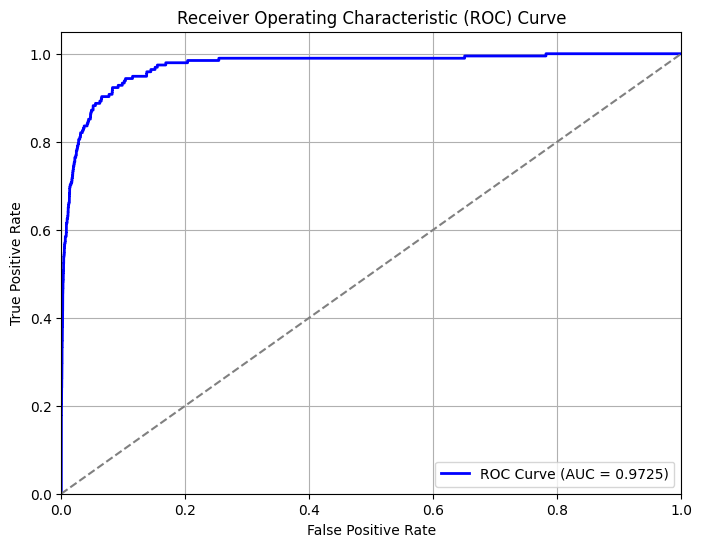

In [16]:
plot_roc_curve(model, test_loader, device)

### ResNet Finetune

In [43]:
model = ResNetFineTune(num_classes=2, freeze_blocks=1).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model_path = "saved_models/resnet_upsampled.pth"


# Train the model
train_model(model, train_loader, test_loader, optimizer=optimizer, criterion=criterion, save_path=model_path, device=device, epochs=50, patience=7)

load_model(model, model_path)

# Evaluate on test set
test_acc, test_auc = evaluate_model(model, test_loader, device)
print(f"Test Accuracy: {test_acc}, Test AUC: {test_auc}")

/home/shubham-mate/Desktop/Programming/Python/DeepLense/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/shubham-mate/Desktop/Programming/Python/DeepLense/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/50: 100%|██████████| 951/951 [00:29<00:00, 32.15it/s]


Epoch 1: Loss = 179.0423834528774, Train Acc = 0.9295510606808091, Val Acc = 0.9368447837150127, AUC = 0.969919010998425
Model saved to saved_models/resnet_upsampled.pth


Epoch 2/50: 100%|██████████| 951/951 [00:29<00:00, 32.19it/s]


Epoch 2: Loss = 98.68404733711213, Train Acc = 0.9640848544647262, Val Acc = 0.9611704834605598, AUC = 0.9780665440958424
Model saved to saved_models/resnet_upsampled.pth


Epoch 3/50: 100%|██████████| 951/951 [00:29<00:00, 32.17it/s]


...

Epoch 8: Loss = 23.818395769732888, Train Acc = 0.9928630159513238, Val Acc = 0.9849872773536895, AUC = 0.9765885771899651


Epoch 9/50: 100%|██████████| 951/951 [00:29<00:00, 32.18it/s]


Epoch 9: Loss = 26.742086000956988, Train Acc = 0.9915145535273804, Val Acc = 0.9846819338422392, AUC = 0.9781305972362256


Epoch 10/50: 100%|██████████| 951/951 [00:29<00:00, 32.24it/s]


Epoch 10: Loss = 21.803112490781132, Train Acc = 0.9936523598092419, Val Acc = 0.9818320610687022, AUC = 0.9807363475212357
Early stopping triggered after 10 epochs.
Model loaded from saved_models/resnet_upsampled.pth
Test Accuracy: 0.9444783715012722, Test AUC: 0.9821499976935598


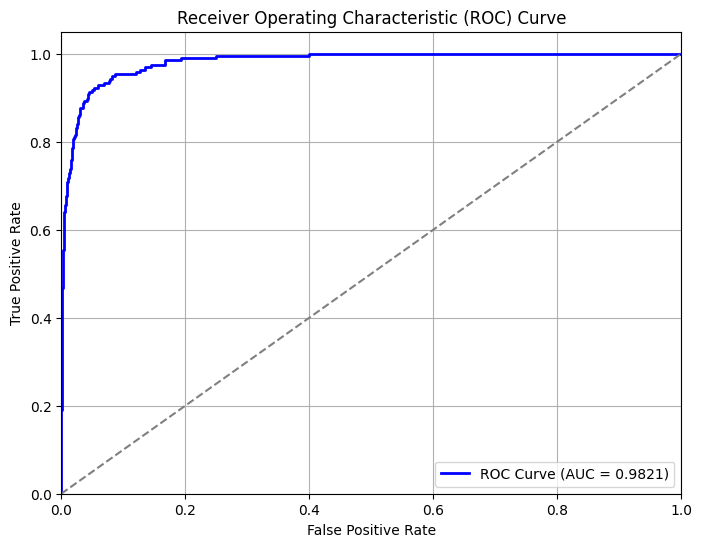

In [44]:
plot_roc_curve(model, test_loader, device)

## Downsampling the majority class

In [45]:
target_class_counts = {0: 1730, 1: 1730}
downsampled_train_dataset = downsample_dataset(train_dataset, target_class_counts)

train_loader = DataLoader(downsampled_train_dataset, batch_size=32, shuffle=True)

### LensCNN

In [32]:
model = LensCNN(num_classes=2).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model_path = "saved_models/cnn_downsampled.pth"


# Train the model
train_model(model, train_loader, test_loader, optimizer=optimizer, criterion=criterion, save_path=model_path, device=device, epochs=50, patience=7)

load_model(model, model_path)

# Evaluate on test set
test_acc, test_auc = evaluate_model(model, test_loader, device)
print(f"Test Accuracy: {test_acc}, Test AUC: {test_auc}")

Epoch 1/50:   0%|          | 0/109 [00:00<?, ?it/s]

Epoch 1/50: 100%|██████████| 109/109 [00:01<00:00, 69.63it/s]


Epoch 1: Loss = 56.207657277584076, Train Acc = 0.7557803468208093, Val Acc = 0.3998473282442748, AUC = 0.8136520174762272
Model saved to saved_models/cnn_downsampled.pth


Epoch 2/50: 100%|██████████| 109/109 [00:01<00:00, 75.98it/s]


Epoch 2: Loss = 48.16791781783104, Train Acc = 0.8095375722543353, Val Acc = 0.6487531806615776, AUC = 0.8888811128903651
Model saved to saved_models/cnn_downsampled.pth


...

Epoch 27: Loss = 21.830686843022704, Train Acc = 0.9280346820809249, Val Acc = 0.7895674300254453, AUC = 0.9572292403903815


Epoch 28/50: 100%|██████████| 109/109 [00:01<00:00, 73.28it/s]


Epoch 28: Loss = 22.808027625083923, Train Acc = 0.922543352601156, Val Acc = 0.9081424936386768, AUC = 0.9576300338058241


Epoch 29/50: 100%|██████████| 109/109 [00:01<00:00, 72.33it/s]


Epoch 29: Loss = 23.07369865477085, Train Acc = 0.9242774566473988, Val Acc = 0.7505343511450382, AUC = 0.9299733111915071
Early stopping triggered after 29 epochs.
Model loaded from saved_models/cnn_downsampled.pth
Test Accuracy: 0.8797455470737914, Test AUC: 0.960415291039809


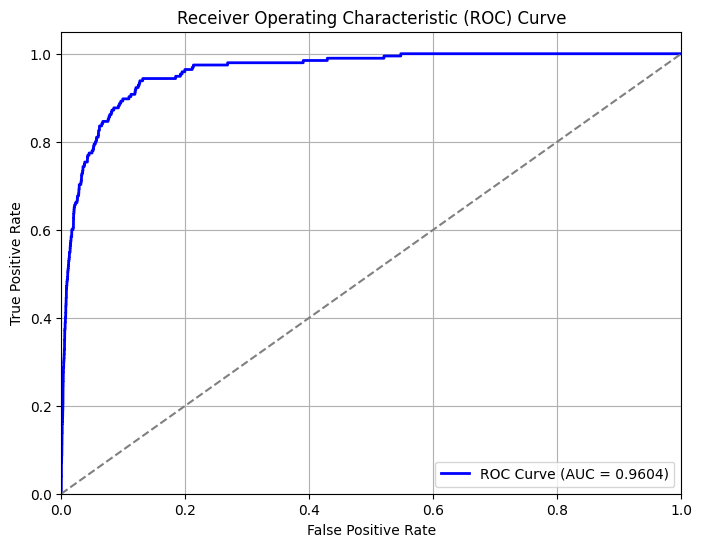

In [33]:
plot_roc_curve(model, test_loader, device)

### ResNet Finetune

In [46]:
model = ResNetFineTune(num_classes=2, freeze_blocks=1).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model_path = "saved_models/resnet_downsampled.pth"


# Train the model
train_model(model, train_loader, test_loader, optimizer=optimizer, criterion=criterion, save_path=model_path, device=device, epochs=50, patience=7)

load_model(model, model_path)

# Evaluate on test set
test_acc, test_auc = evaluate_model(model, test_loader, device)
print(f"Test Accuracy: {test_acc}, Test AUC: {test_auc}")

/home/shubham-mate/Desktop/Programming/Python/DeepLense/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/shubham-mate/Desktop/Programming/Python/DeepLense/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/50: 100%|██████████| 109/109 [00:03<00:00, 31.94it/s]


Epoch 1: Loss = 36.90256541967392, Train Acc = 0.8736994219653179, Val Acc = 0.8006106870229007, AUC = 0.9382121793224338
Model saved to saved_models/resnet_downsampled.pth


Epoch 2/50: 100%|██████████| 109/109 [00:03<00:00, 32.08it/s]


Epoch 2: Loss = 26.016279138624668, Train Acc = 0.9095375722543353, Val Acc = 0.9687022900763359, AUC = 0.9701346302117313
Model saved to saved_models/resnet_downsampled.pth


Epoch 3/50: 100%|██████████| 109/109 [00:03<00:00, 32.25it/s]


...

Epoch 16: Loss = 12.498281113919802, Train Acc = 0.9815028901734104, Val Acc = 0.8939949109414759, AUC = 0.9703622429142861


Epoch 17/50: 100%|██████████| 109/109 [00:03<00:00, 32.17it/s]


Epoch 17: Loss = 23.745763385668397, Train Acc = 0.9199421965317919, Val Acc = 0.8913994910941476, AUC = 0.9697795702113359


Epoch 18/50: 100%|██████████| 109/109 [00:03<00:00, 32.31it/s]


Epoch 18: Loss = 12.152591865509748, Train Acc = 0.9641618497109826, Val Acc = 0.9102290076335878, AUC = 0.9640049028329677
Early stopping triggered after 18 epochs.
Model loaded from saved_models/resnet_downsampled.pth
Test Accuracy: 0.9575063613231553, Test AUC: 0.977040639477031


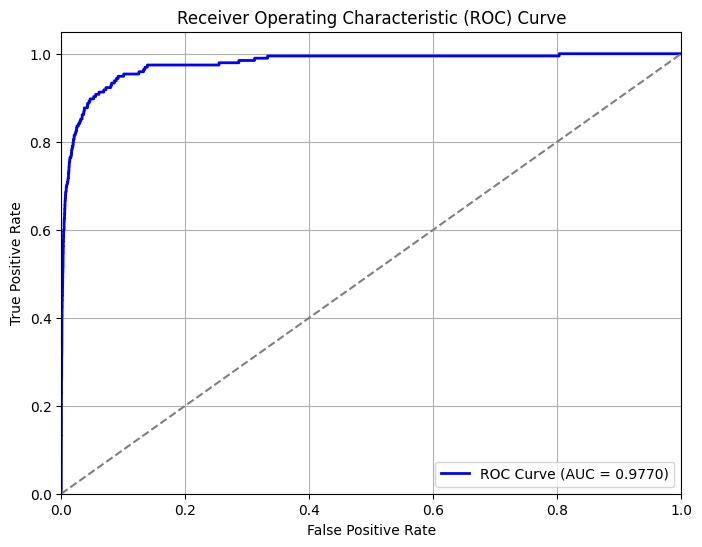

In [47]:
plot_roc_curve(model, test_loader, device)